**Introduction** This is actually my first public kernel, so I hope it will be useful for someone.

Before you read the notebook, it is important to know that this notebook is a compilation of already existing notebooks and some model modifications. Here is list of notebooks:

* Data analysis - https://www.kaggle.com/muonneutrino/exploration-transforming-images-in-python
* Image conversion, Network architecture - https://www.kaggle.com/tivigovidiu/keras-model-for-beginners-0-210-on-lb-eda-r-d
* Some ideas - https://www.kaggle.com/knowledgegrappler/a-keras-prototype-0-21174-on-pl
* Code for conversion to image provided by MadScientist but I don't know which kernel it is.

Before running the model it is good idea to run through kernels mentioned here and upvote them.

**Comments** I've executed this code on my machine with 1080 TI and it may be pretty slow if you have low-end GPU or CPU

It is also important that I don't know how to execute code in the notebook with GPU, since keras is not freeing memory after model training, so train results here may be uncomplete.

I am also not sure about random seed initialization and haven't checked it, so maybe your results may differ from mine.

I am also sorry for a WinAPI style functions with 10+ arguments, but this solution was made less than in a one day and basically my second solution. If someone is able to rewrite it in a normal style I will appreciate that, so feel free to fork and rewrite.

In [35]:
import numpy as np
np.random.seed(98643)
import tensorflow as tf
tf.random.set_seed(683)

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

from skimage.restoration import (denoise_tv_chambolle, denoise_bilateral, denoise_wavelet, estimate_sigma, denoise_tv_bregman, denoise_nl_means)
from skimage.filters import gaussian
from skimage.color import rgb2gray

import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.preprocessing import MinMaxScaler

from tf_keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Input, Flatten, GlobalAveragePooling2D, Lambda
from tf_keras.layers import GlobalMaxPooling2D
from tf_keras.layers import BatchNormalization
from tf_keras.layers import Concatenate
from tf_keras.models import Model
from tf_keras.models import Model
from tf_keras.optimizers.legacy import Adam
from tf_keras.callbacks import ModelCheckpoint, Callback, EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from tf_keras.preprocessing.image import ImageDataGenerator

First of all, some data preprocessing is required.

The basic idea is that images, that provided in a dataset are very noisy and if we will get rid of granular noise, we will be able to predict better and construct noisy dataset by our own.

It is also interesting to train a denoising autoencoder on dataset in order to extract some global features that may be used further on model training.

In [36]:
def color_composite(data):
    rgb_arrays = []
    for i, row in data.iterrows():
        band_1 = np.array(row['band_1']).reshape(75, 75)
        band_2 = np.array(row['band_2']).reshape(75, 75)
        band_3 = band_1 / band_2

        r = (band_1 + abs(band_1.min())) / np.max((band_1 + abs(band_1.min())))
        g = (band_2 + abs(band_2.min())) / np.max((band_2 + abs(band_2.min())))
        b = (band_3 + abs(band_3.min())) / np.max((band_3 + abs(band_3.min())))

        rgb = np.dstack((r, g, b))
        rgb_arrays.append(rgb)
    return np.array(rgb_arrays)

def denoise(X, weight, channel_axis):
    return np.asarray([denoise_tv_chambolle(item, weight=weight, channel_axis=channel_axis) for item in X])

def smooth(X, sigma):
    return np.asarray([gaussian(item, sigma=sigma) for item in X])

def grayscale(X):
    return np.asarray([rgb2gray(item) for item in X])

In [37]:
train = pd.read_json('./input/train.json')
train.inc_angle = train.inc_angle.replace('na', 0)
train.inc_angle = train.inc_angle.astype(float).fillna(0.0)
train_all = True

train_b = True or train_all
train_img = True or train_all
train_total = True or train_all
predict_submission = True and train_all

clean_all = False
clean_b = False or clean_all
clean_img = False or clean_all

load_all = False
load_b = False or load_all
load_img = False or load_all

C:\Users\USER\AppData\Local\Temp\ipykernel_31156\3372207913.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  train.inc_angle = train.inc_angle.replace('na', 0)


In [38]:
def create_dataset(frame, labeled, smooth_rgb=0.2, smooth_gray=0.5, weight_rgb=0.05, weight_gray=0.05):
    band_1, band_2, images = frame['band_1'].values, frame['band_2'].values, color_composite(frame)
    to_arr = lambda x: np.asarray([np.asarray(item) for item in x])
    band_1 = to_arr(band_1)
    band_2 = to_arr(band_2)
    band_3 = (band_1 + band_2) / 2
    gray_reshape = lambda x: np.asarray([item.reshape(75, 75) for item in x])
    
    band_1 = gray_reshape(band_1)
    band_2 = gray_reshape(band_2)
    band_3 = gray_reshape(band_3)
    print('Denoising and reshaping')
    if train_b and clean_b:
        band_1 = smooth(denoise(band_1, weight_gray, False), smooth_gray)
        print('Gray 1 done')
        band_2 = smooth(denoise(band_2, weight_gray, False), smooth_gray)
        print('Gray 2 done')
        band_3 = smooth(denoise(band_3, weight_gray, False), smooth_gray)
        print('Gray 3 done')
    if train_img and clean_img:
        images = smooth(denoise(images, weight_rgb, True), smooth_rgb)
    print('RGB done')
    tf_reshape = lambda x: np.asarray([item.reshape(75, 75, 1) for item in x])
    band_1 = tf_reshape(band_1)
    band_2 = tf_reshape(band_2)
    band_3 = tf_reshape(band_3)

    band = np.concatenate([band_1, band_2, band_3], axis=3)
    if labeled:
        y = np.array(frame['is_iceberg'])
    else:
        y = None
    return y, band, images

In [39]:
y_train, X_b, X_images = create_dataset(train, True)

Denoising and reshaping
RGB done


Plotting some random images to check how cleaning works

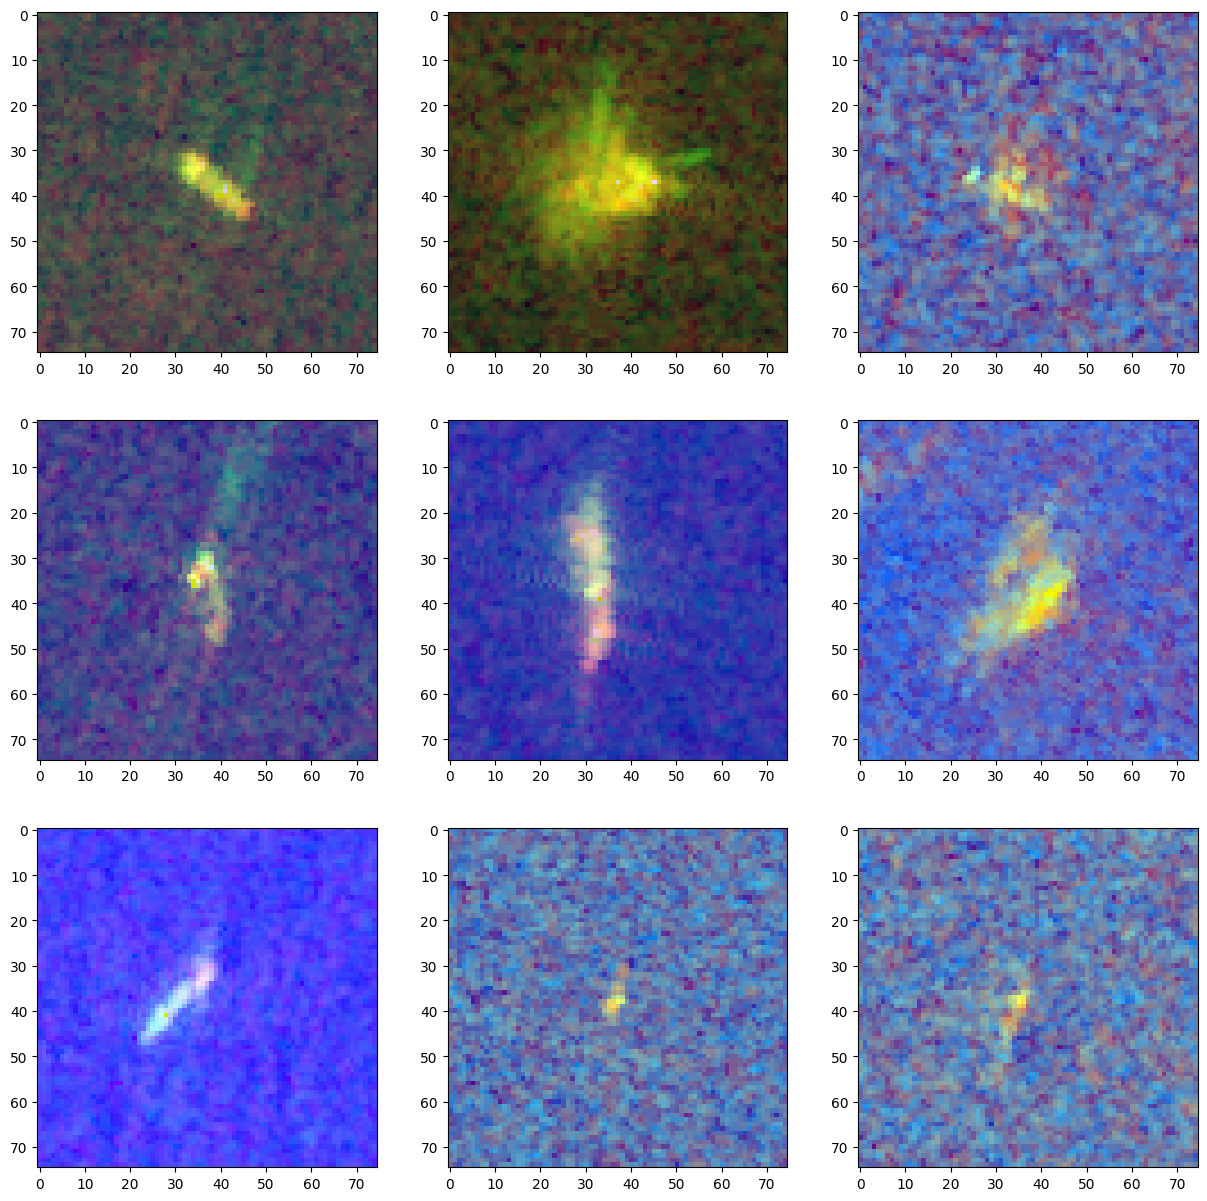

In [40]:
fig = plt.figure(200, figsize=(15, 15))
random_indicies = np.random.choice(range(len(X_images)), 9, False)
subset = X_images[random_indicies]
for i in range(9):
    ax = fig.add_subplot(3, 3, i+1)
    ax.imshow(subset[i])
plt.show()

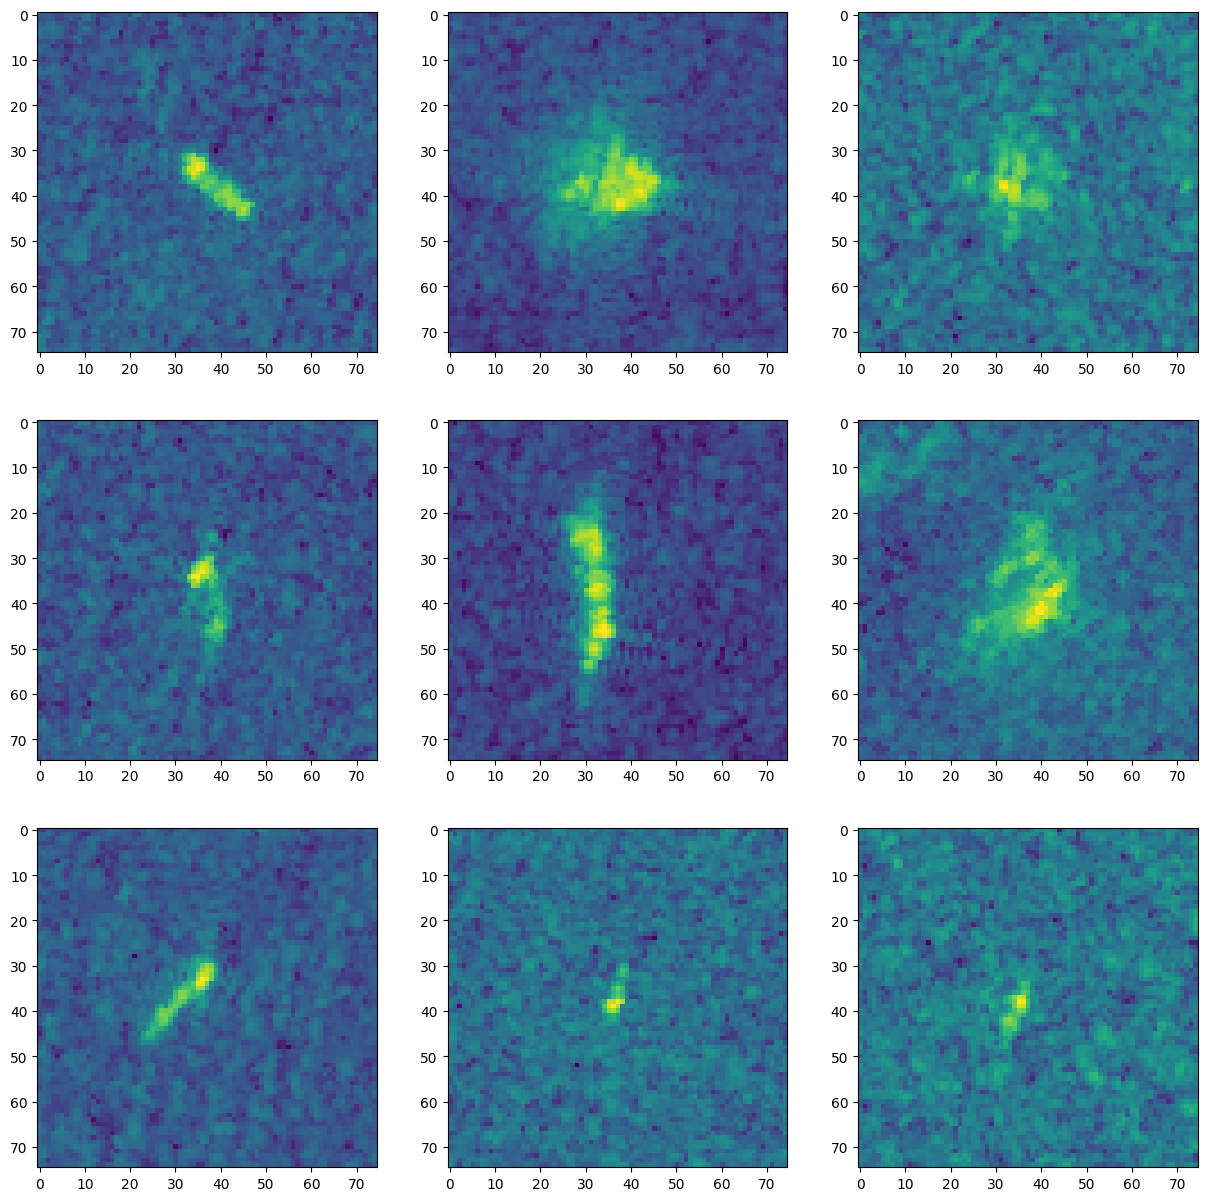

In [41]:
fig = plt.figure(202, figsize=(15, 15))
band_1_x = train['band_1'].values
subset = np.asarray(band_1_x)[random_indicies]
subset = np.asarray([np.asarray(item).reshape(75, 75) for item in subset])
for i in range(9):
    ax = fig.add_subplot(3, 3, i+1)
    ax.imshow(subset[i])
plt.show()

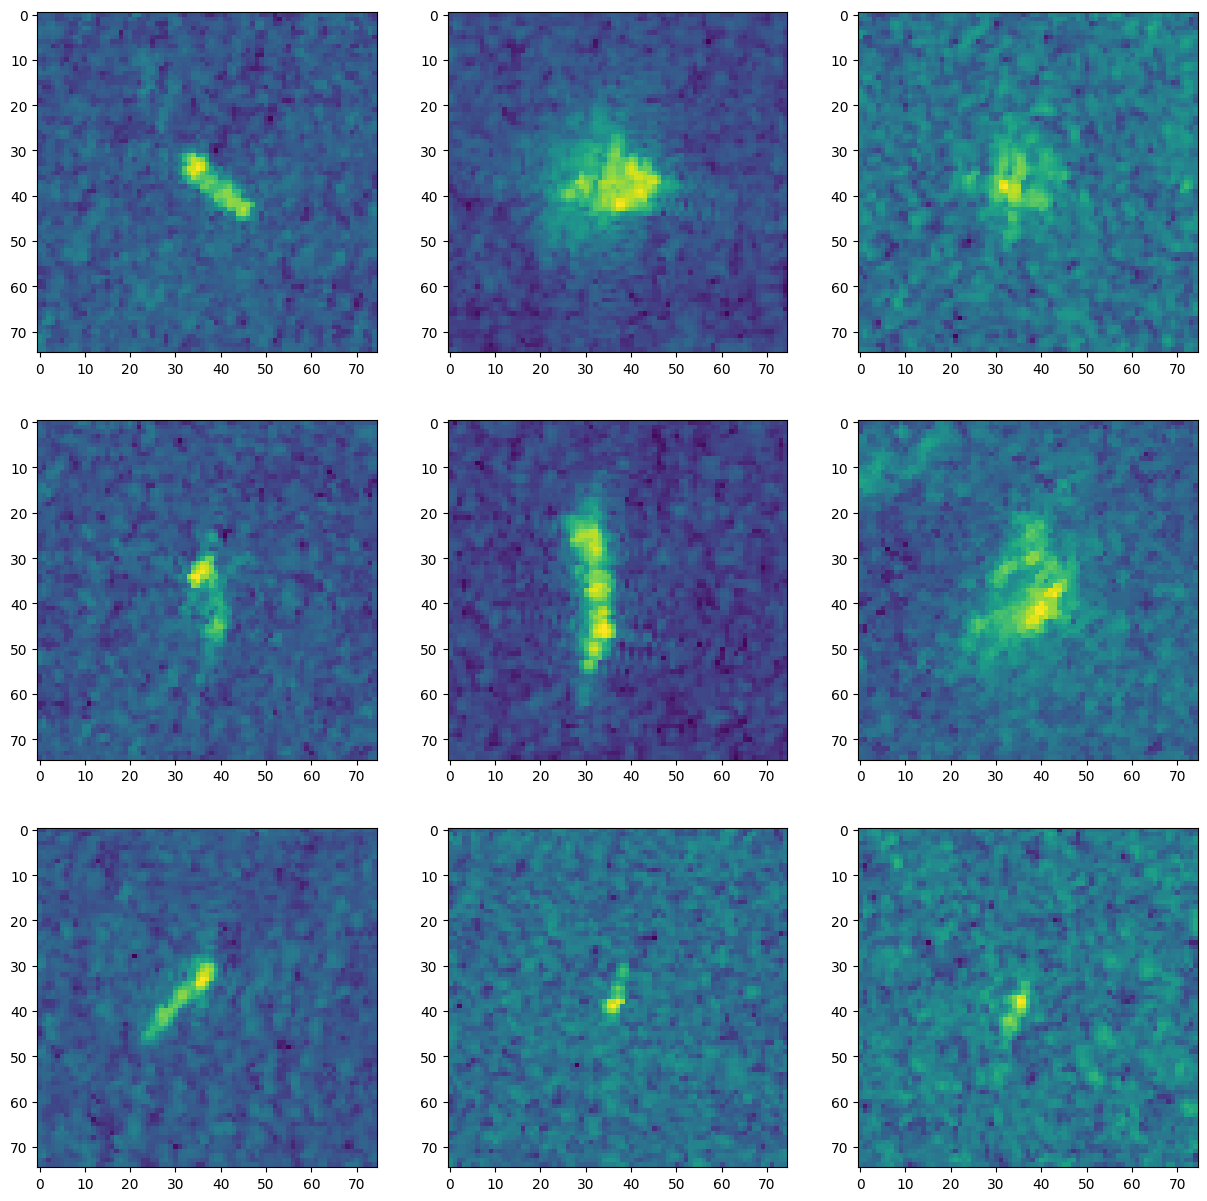

In [42]:
fig = plt.figure(202, figsize=(15, 15))
subset = np.asarray(band_1_x)[random_indicies]
subset = denoise(np.asarray([np.asarray(item).reshape(75, 75) for item in subset]), 0.05, None)
for i in range(9):
    ax = fig.add_subplot(3, 3, i+1)
    ax.imshow(subset[i])
plt.show()

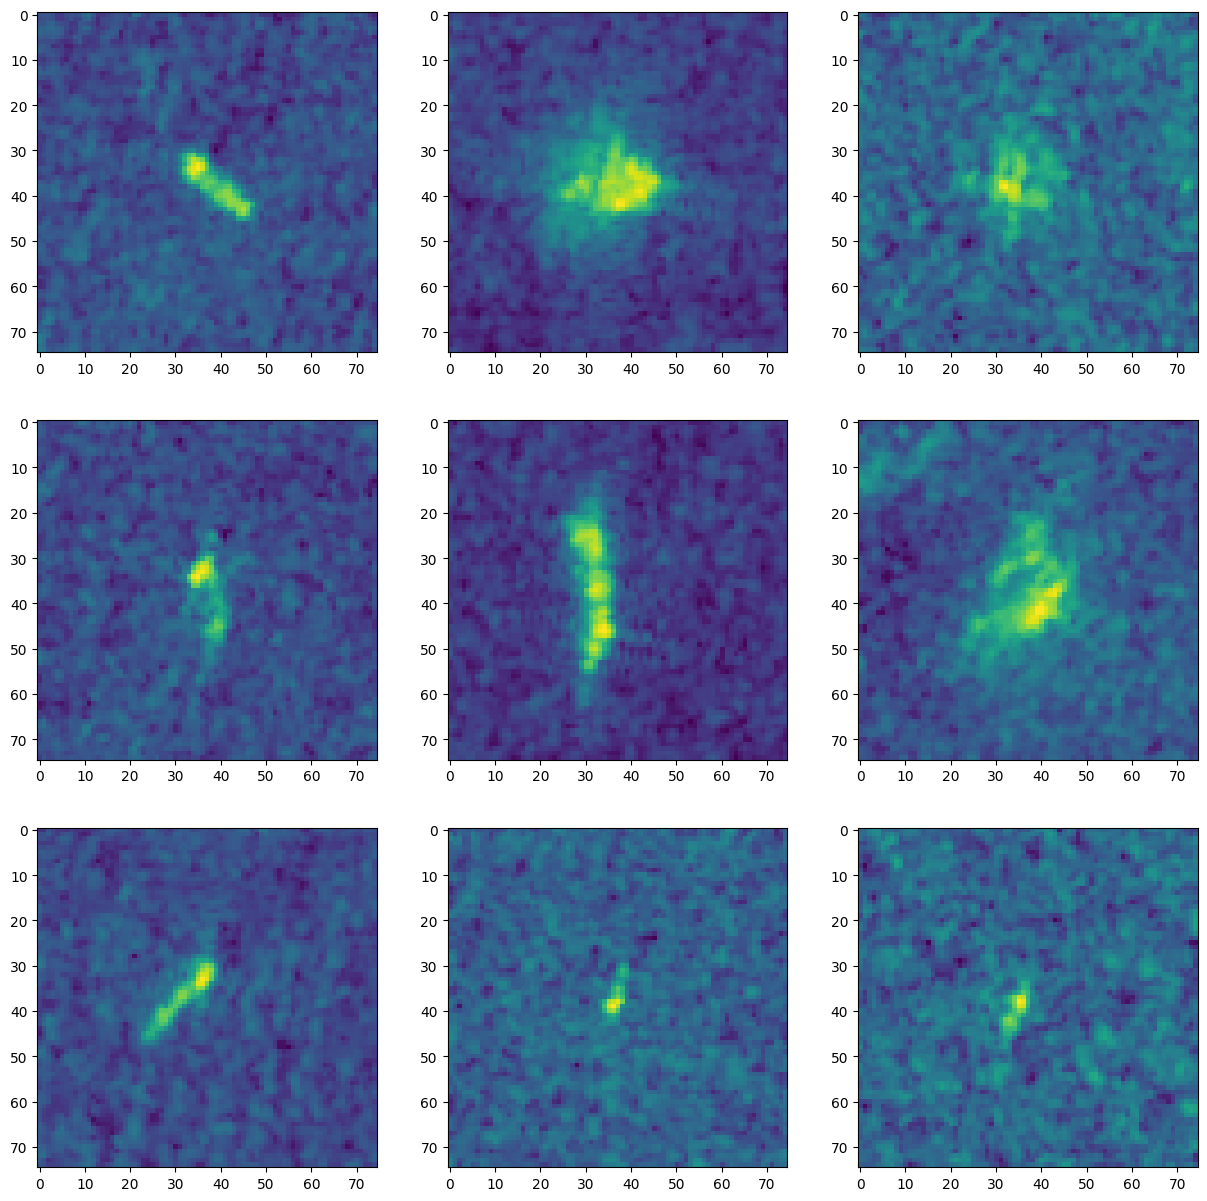

In [43]:
fig = plt.figure(202, figsize=(15, 15))
subset = np.asarray(band_1_x)[random_indicies]
subset = smooth(denoise(np.asarray(
    [np.asarray(item).reshape(75, 75) for item in subset]), 0.05, None
), 0.5)
for i in range(9):
    ax = fig.add_subplot(3, 3, i+1)
    ax.imshow(subset[i])
plt.show()

**A few words about model**

The model itself consists of 3 convolutional neural networks. Two basic networks and one combined. The idea is to train two basic networks on different data representations and after that, using trained convolutional layers in combination to train common network.

Architecture for these networks is taken from notebook mentioned in the very beginning.

For training I'm using 3 datasets, 1 that network sees only once and default keras val split for model selection.

In [44]:
def get_model_notebook(lr, decay, channels, relu_type='relu'):
    input_1 = Input(shape=(75, 75, channels))

    fcnn = Conv2D(32, kernel_size=(3, 3), activation=relu_type)(BatchNormalization()(input_1))
    fcnn = MaxPooling2D((3, 3))(fcnn)
    fcnn = Dropout(0.2)(fcnn)
    fcnn = Conv2D(128, kernel_size=(3, 3), activation=relu_type)(fcnn)
    fcnn = MaxPooling2D((2, 2), strides=(2, 2))(fcnn)
    fcnn = Dropout(0.2)(fcnn)
    fcnn = Conv2D(128, kernel_size=(3, 3), activation=relu_type)(fcnn)
    fcnn = MaxPooling2D((2, 2), strides=(2, 2))(fcnn)
    fcnn = Dropout(0.2)(fcnn)
    fcnn = Conv2D(128, kernel_size=(3, 3), activation=relu_type)(fcnn)
    fcnn = MaxPooling2D((2, 2), strides=(2, 2))(fcnn)
    fcnn = Dropout(0.2)(fcnn)
    fcnn = BatchNormalization()(fcnn)
    fcnn = Flatten()(fcnn)
    local_input = input_1
    partial_model = Model(input_1, fcnn)
    dense = Dropout(0.2)(fcnn)
    dense = Dense(256, activation=relu_type)(dense)
    dense = Dropout(0.2)(dense)
    dense = Dense(128, activation=relu_type)(dense)
    dense = Dropout(0.2)(dense)
    dense = Dense(64, activation=relu_type)(dense)
    dense = Dropout(0.2)(dense)

    output = Dense(1, activation='sigmoid')(dense)
    model = Model(local_input, output)
    optimizer = Adam(lr=lr, decay=decay)
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    return model, partial_model

In [45]:
def combined_model(m_b, m_img, lr, decay):
    input_b = Input(shape=(75, 75, 3))
    input_img = Input(shape=(75, 75, 3))

    m1 = m_b(input_b)
    m2 = m_img(input_img)

    common = Concatenate()([m1, m2])
    common = BatchNormalization()(common)
    common = Dropout(0.3)(common)
    common = Dense(1024, activation='relu')(common)
    common = Dropout(0.3)(common)
    common = Dense(512, activation='relu')(common)
    common = Dropout(0.3)(common)
    output = Dense(1, activation='sigmoid')(common)
    model = Model([input_b, input_img], output)
    optimizer = Adam(lr=lr, beta_1=0.9, beta_2=0.999, epsilon=1e-08, decay=decay)
    model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    return model

In [46]:
def gen_flow_multi_inputs(I1, I2, y, batch_size):
    gen1 = ImageDataGenerator(horizontal_flip=True,
                              vertical_flip=True,
                              width_shift_range=0.,
                              height_shift_range=0.,
                              channel_shift_range=0,
                              zoom_range=0.2,
                              rotation_range=10)
    gen2 = ImageDataGenerator(horizontal_flip=True,
                              vertical_flip=True,
                              width_shift_range=0.,
                              height_shift_range=0.,
                              channel_shift_range=0,
                              zoom_range=0.2,
                              rotation_range=10)
    genI1 = gen1.flow(I1, y, batch_size=batch_size, seed=57, shuffle=False)
    genI2 = gen2.flow(I1, I2, batch_size=batch_size, seed=57, shuffle=False)
    while True:
        I1i = genI1.next()
        I2i = genI2.next()

        np.testing.assert_array_equal(I2i[0], I1i[0])
        yield [I1i[0], I2i[1]], I1i[1]

In [47]:
def train_model(model, batch_size, epochs, checkpoint_name, X_train, y_train, val_data, verbose=2):
    callbacks = [ModelCheckpoint(checkpoint_name, save_best_only=True, save_weights_only=True, monitor='val_loss')]
    datagen = ImageDataGenerator(horizontal_flip=True,
                                 vertical_flip=True,
                                 width_shift_range=0.,
                                 height_shift_range=0.,
                                 channel_shift_range=0,
                                 zoom_range=0.2,
                                 rotation_range=10)
    x_test, y_test = val_data
    try:
        model.fit_generator(datagen.flow(X_train, y_train, batch_size=batch_size), epochs=epochs,
                            steps_per_epoch=len(X_train) / batch_size,
                            validation_data=(x_test, y_test), verbose=1,
                            callbacks=callbacks)
    except KeyboardInterrupt:
        if verbose > 0:
            print('Interrupted')
    if verbose > 0:
        print('Loading model')
    model.load_weights(filepath=checkpoint_name)
    return model

In [48]:
def gen_model_weights(lr, decay, channels, relu, batch_size, epochs, path_name, data, verbose=2):
    X_train, y_train, X_test, y_test, X_val, y_val = data
    model, partial_model = get_model_notebook(lr, decay, channels, relu)
    model = train_model(model, batch_size, epochs, path_name, X_train, y_train, (X_test, y_test), verbose=verbose)

    if verbose > 0:
        loss_val, acc_val = model.evaluate(X_val, y_val, verbose=0, batch_size=batch_size)

        loss_train, acc_train = model.evaluate(X_test, y_test, verbose=0, batch_size=batch_size)

        print('Val/Train Loss:', str(loss_val) + '/' + str(loss_train), 'Val/Train Acc:', str(acc_val) + '/' + str(acc_train))
    return model, partial_model

In [49]:
def train_models(dataset, lr, batch_size, max_epoch, verbose=2, return_model=False):
    y_train, X_b, X_images = dataset
    y_train_full, y_val, X_b_full, X_b_val, X_images_full, X_images_val = train_test_split(y_train, X_b, X_images, random_state=687, train_size=0.9)

    y_train, y_test, X_b_train, X_b_test, X_images_train, X_images_test = train_test_split(y_train_full, X_b_full, X_images_full, random_state=576, train_size=0.85)

    if train_b:
        if verbose > 0:
            print('Training bandwidth network')
        data_b1 = (X_b_train, y_train, X_b_test, y_test, X_b_val, y_val)
        model_b, model_b_cut = gen_model_weights(lr, 1e-6, 3, 'relu', batch_size, max_epoch, 'model_b.weights.h5', data=data_b1, verbose=verbose)

    if train_img:
        if verbose > 0:
            print('Training image network')
        data_images = (X_images_train, y_train, X_images_test, y_test, X_images_val, y_val)
        model_images, model_images_cut = gen_model_weights(lr, 1e-6, 3, 'relu', batch_size, max_epoch, 'model_img.weights.h5', data_images, verbose=verbose)
    
    if train_total:
        common_model = combined_model(model_b_cut, model_images_cut, lr/2, 1e-7)
        common_x_train = [X_b_full, X_images_full]
        common_y_train = y_train_full
        common_x_val = [X_b_val, X_images_val]
        common_y_val = y_val
        if verbose > 0:
            print('Training common network')
        callbacks = [ModelCheckpoint('common.weights.h5', save_best_only=True, save_weights_only=True, monitor='val_loss')]
        try:
            common_model.fit_generator(gen_flow_multi_inputs(X_b_full, X_images_full, y_train_full, batch_size), epochs=30, steps_per_epoch=len(X_b_full) / batch_size, validation_data=(common_x_val, common_y_val), verbose=1, callbacks=callbacks)
        except KeyboardInterrupt:
            pass
        common_model.load_weights(filepath='common.weights.h5')
        loss_val, acc_val = common_model.evaluate(common_x_val, common_y_val, verbose=0, batch_size=batch_size)
        loss_train, acc_train = common_model.evaluate(common_x_train, common_y_train, verbose=0, batch_size=batch_size)
        if verbose > 0:
            print('Loss:', loss_val, 'Acc:', acc_val)
    if return_model:
        return common_model
    else:
        return (loss_train, acc_train), (loss_val, acc_val)

Model parameters that are used in training assumes that you have enough computational power to process all the data.

(Don't know if it is obvious or not) The important moment here is to save 3 sets, since if you are selecting model based on a validation set it affects final performance since it causes indirect observations of validation set and affect final evaluation score.

In [ ]:
common_model = train_models((y_train, X_b, X_images), 7e-04, 32, 50, 1, return_model=True)

Training bandwidth network
Epoch 1/50


c:\Users\USER\AppData\Local\Programs\Python\Python311\Lib\site-packages\tf_keras\src\optimizers\legacy\adam.py:118: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)
C:\Users\USER\AppData\Local\Temp\ipykernel_31156\2095403234.py:12: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  model.fit_generator(datagen.flow(X_train, y_train, batch_size=batch_size), epochs=epochs,


38/38 [==============================] - 4s 83ms/step - loss: 0.6658 - accuracy: 0.5808 - val_loss: 2.5129 - val_accuracy: 0.5253
Epoch 2/50
38/38 [==============================] - 2s 47ms/step - loss: 0.6198 - accuracy: 0.6338 - val_loss: 3.4278 - val_accuracy: 0.5253
Epoch 3/50
38/38 [==============================] - 2s 51ms/step - loss: 0.5860 - accuracy: 0.6558 - val_loss: 0.6023 - val_accuracy: 0.5991
Epoch 4/50
38/38 [==============================] - 2s 49ms/step - loss: 0.5618 - accuracy: 0.6909 - val_loss: 0.6167 - val_accuracy: 0.6452
Epoch 5/50
38/38 [==============================] - 2s 49ms/step - loss: 0.5053 - accuracy: 0.7423 - val_loss: 0.7302 - val_accuracy: 0.5300
Epoch 6/50
38/38 [==============================] - 2s 47ms/step - loss: 0.4734 - accuracy: 0.7700 - val_loss: 0.4704 - val_accuracy: 0.7558
Epoch 7/50
38/38 [==============================] - 2s 43ms/step - loss: 0.4678 - accuracy: 0.7798 - val_loss: 0.8774 - val_accuracy: 0.5392
Epoch 8/50
38/38 [======

*The filtration step for RGB images may take a lot of time*

In [ ]:
if predict_submission:
    print('Reading test dataset')
    test = pd.read_json('./input/test.json')
    y_fin, X_fin_b, X_fin_img = create_dataset(test, False)
    print('Predicting')
    prediction = common_model.predict([X_fin_b, X_fin_img], verbose=1, batch_size=32)
    print('Submitting')
    submission = pd.DataFrame({'id': test['id'], 'is_iceberg': prediction.reshape((prediction.shape[0]))})

    submission.to_csv('./submission.csv', index=False)
    print('Done')

**TODO**:

* Add features from https://www.kaggle.com/muonneutrino/exploration-transforming-images-in-python
* Modify base model and train different models for pictures and bandwidth
* Select denoising algorithm more meaningfully
* Use XBG on output features of convolutional nets
* Train denoising autoencoder on train and test data or extract additional features and clean data
* Data preprocessing parallelization